<a href="https://colab.research.google.com/github/zly554411-arch/ECON3916-Statistical-Machine-Learning/blob/main/Lab%2014/Lab_14_Residual_Forensics%2C_The_White_Test%2C_and_Structural_Diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Ingestion and Naive Baseline Model
url = 'https://raw.githubusercontent.com/zly554411-arch/ECON3916-Statistical-Machine-Learning/refs/heads/main/Nvidia_AI_Capex_Diagnostics_2026.csv'
df = pd.read_csv(url)

formula = 'AI_Software_Revenue ~ Hardware_Capex + Cloud_GPU_Deployments'
baseline_model = smf.ols(formula, data=df).fit()
# delete "data"

print("--- NAIVE BASELINE OLS MODEL ---")
print(baseline_model.summary())

--- NAIVE BASELINE OLS MODEL ---
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     4258.
Date:                 Mon, 23 Mar 2026   Prob (F-statistic):          3.80e-192
Time:                         20:19:08   Log-Likelihood:                -1409.9
No. Observations:                  250   AIC:                             2826.
Df Residuals:                      247   BIC:                             2836.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

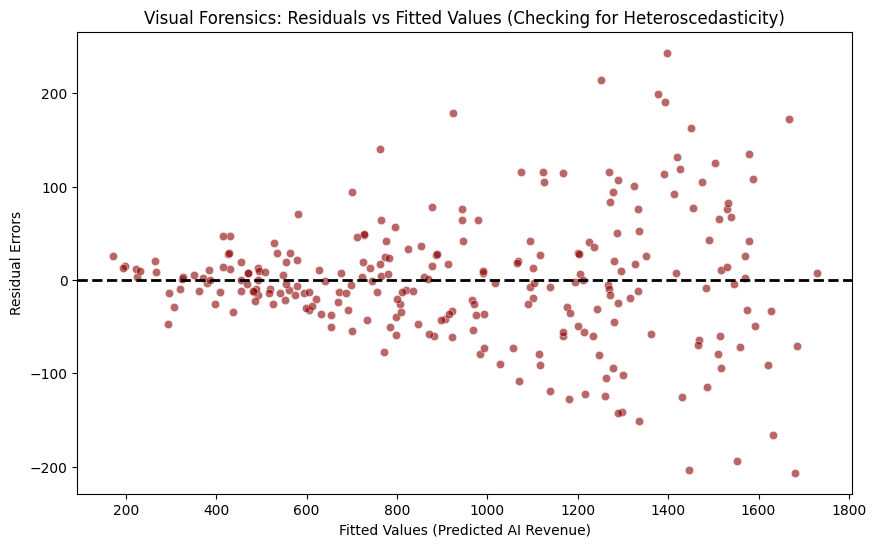

In [ ]:
# Step 2: Visual Forensics
fitted_vals = baseline_model.fittedvalues
residuals = baseline_model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.6, color='darkred')
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Visual Forensics: Residuals vs Fitted Values (Checking for Heteroscedasticity)')
plt.xlabel('Fitted Values (Predicted AI Revenue)')
plt.ylabel('Residual Errors')
plt.show()

In [ ]:
# Step 3: The White Test Execution
# We must extract the design matrix generated by the formula interface
exog_matrix = baseline_model.model.exog
white_test_results = het_white(baseline_model.resid, exog_matrix)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("\n--- WHITE TEST RESULTS ---")
print(dict(zip(labels, [f"{x:.2f}" for x in white_test_results])))


--- WHITE TEST RESULTS ---
{'LM Statistic': '51.64', 'LM-Test p-value': '0.00', 'F-Statistic': '12.70', 'F-Test p-value': '0.00'}


In [ ]:
# Step 4: Variance Inflation Factor (VIF) Loop
print("\n--- VARIANCE INFLATION FACTORS ---")

# Start loop at 1 to skip the constant intercept column at index 0
for i in range(1, exog_matrix.shape[1]):
    vif = variance_inflation_factor(exog_matrix, i)
    print(dict(zip(labels, [f"{x:.2f}" for x in white_test_results])))


--- VARIANCE INFLATION FACTORS ---
{'LM Statistic': '51.64', 'LM-Test p-value': '0.00', 'F-Statistic': '12.70', 'F-Test p-value': '0.00'}
{'LM Statistic': '51.64', 'LM-Test p-value': '0.00', 'F-Statistic': '12.70', 'F-Test p-value': '0.00'}


In [ ]:
# Step 5: The Correction - HC3 Robust Standard Errors
robust_model = smf.ols('AI_Software_Revenue ~ Hardware_Capex + Cloud_GPU_Deployments', data=df).fit(cov_type='HC3')

print("\n--- ROBUST OLS MODEL (HC3) ---")
print(robust_model.summary())



--- ROBUST OLS MODEL (HC3) ---
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     3555.
Date:                 Mon, 23 Mar 2026   Prob (F-statistic):          9.05e-183
Time:                         20:19:08   Log-Likelihood:                -1409.9
No. Observations:                  250   AIC:                             2826.
Df Residuals:                      247   BIC:                             2836.
Df Model:                            2                                         
Covariance Type:                   HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------